# Ensemble Methods


## Variable Target: Rating

### Bagging

In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import randint, uniform
import joblib


In [70]:
df = pd.read_csv('../train_set/train_cleaned_outliers.csv')
train = df.drop(columns=['originalTitle'])

test = pd.read_csv('../test_set/test_no_title.csv')

# mapping of classes
# 0: 1-4
# 1: 5
# 2: 6
# 3: 7
# 4: 8
# 5: 9-10

def rating_to_class(rating):
    if rating <= 4:
        return 0
    elif rating == 5:
        return 1
    elif rating == 6:
        return 2
    elif rating == 7:
        return 3
    elif rating == 8:
        return 4
    else:  # rating 9 or 10
        return 5

# Applica la trasformazione
train['rating_target'] = train['rating'].apply(rating_to_class)
test['rating_target'] = test['rating'].apply(rating_to_class)

# plot class distribution

label_map = {
    0: '1–4',
    1: '5',
    2: '6',
    3: '7',
    4: '8',
    5: '9–10'
}


In [71]:
X_train = train.drop(columns=['rating', "averageRating", "rating_target"])
y_train = train['rating_target']

X_test = test.drop(columns=['rating', "averageRating", "rating_target", "genreShort"])
y_test = test['rating_target']

In [72]:
# base_tree = DecisionTreeClassifier()

# # Bagging setup
# bagging = BaggingClassifier(estimator=base_tree, random_state=42)

# # Parametri più ampi per halving search
# param_dist_bagging = {
#     'n_estimators': randint(50, 300),
#     'max_samples': uniform(0.3, 0.7),  # da 0.3 a 1.0
#     'max_features': uniform(0.5, 0.5),  # da 0.5 a 1.0
#     'estimator__max_depth': [5, 10, 15, 20, 30, 50],
#     'estimator__min_samples_split': randint(2, 20),
#     'estimator__min_samples_leaf': randint(1, 10),
#     'estimator__criterion': ['gini', 'entropy'],
#     'estimator__max_features': ['sqrt', 'log2', 0.5, 0.7],
# }

# # Halving Random Search con molte più combinazioni
# _bagging = HalvingRandomSearchCV(
#     estimator=bagging,
#     param_distributions=param_dist_bagging,
#     factor=1.5,  # Elimina 2/3 dei candidati ad ogni iterazione
#     scoring='f1_macro', 
#     cv=8,
#     verbose=2,
#     n_jobs=-1,
#     random_state=42
# )

# _bagging.fit(X_train, y_train)

# # best model fitting
# best_model = _bagging.best_estimator_
# print("Best params Bagging:", _bagging.best_params_)

# joblib.dump(best_model, './models/bagging_rating.pkl')


In [73]:
# load model
best_model = joblib.load('./models/bagging_rating.pkl')

y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.42      0.15      0.22      1184
           1       0.42      0.18      0.25      2199
           2       0.37      0.30      0.33      5090
           3       0.41      0.43      0.42      9375
           4       0.49      0.66      0.56     11892
           5       0.50      0.38      0.43      6555

    accuracy                           0.45     36295
   macro avg       0.43      0.35      0.37     36295
weighted avg       0.45      0.45      0.44     36295



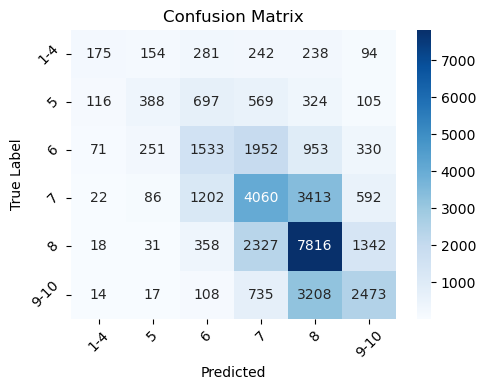

In [ ]:
# ...existing code...
label_map = {
    0: "1-4",
    1: "5",
    2: "6",
    3: "7",
    4: "8",
    5: "9-10"
}

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))

# Crea le label per gli assi usando il mapping
class_labels = [label_map[i] for i in sorted(np.unique(y_test))]

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_labels,  # Label testuali per asse X
    yticklabels=class_labels   # Label testuali per asse Y
)

plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True Label')
plt.tight_layout()  # Per migliorare il layout
plt.show()


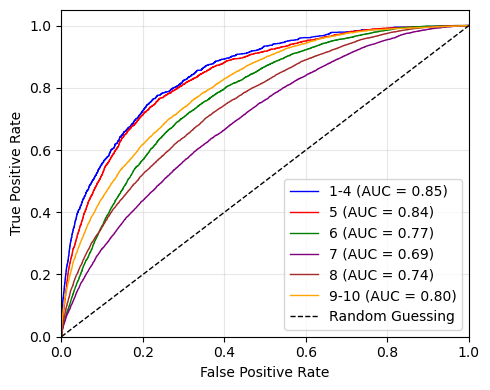


ROC AUC per classe:
1-4: 0.849
5: 0.837
6: 0.771
7: 0.694
8: 0.744
9-10: 0.802

ROC AUC media: 0.783


In [ ]:
# ...existing code...
# ROC curve per multiclass
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarizza solo le etichette di test
y_test_bin = label_binarize(y_test, classes=sorted(np.unique(y_test)))
n_classes = y_test_bin.shape[1]

# compute y_pred_proba
y_pred_proba = best_model.predict_proba(X_test)

# Calcola le curve ROC e AUC per ogni classe
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot delle curve ROC
plt.figure(figsize=(5, 4))
colors = ['blue', 'red', 'green', 'purple', 'brown', 'orange']

for i in range(n_classes):
    plt.plot(
        fpr[i], tpr[i], 
        color=colors[i % len(colors)],
        lw=1,
        label=f'{label_map[i]} (AUC = {roc_auc[i]:.2f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calcola anche la ROC AUC media
print(f"\nROC AUC per classe:")
for i in range(n_classes):
    print(f"{label_map[i]}: {roc_auc[i]:.3f}")
print(f"\nROC AUC media: {np.mean(list(roc_auc.values())):.3f}")

### Random Forest

In [76]:
# rf = RandomForestClassifier(random_state=42)

# # Parametri molto più ampi per halving search
# param_dist_rf = {
#     'n_estimators': randint(100, 500),
#     'max_depth': [5, 10, 15, 20, 30, 50, 75, 100],
#     'max_features': ['sqrt', 'log2', None, 0.3, 0.5, 0.7],
#     'min_samples_split': randint(2, 20),
#     'min_samples_leaf': randint(1, 10),
#     'criterion': ['gini', 'entropy'],
#     'bootstrap': [True, False],
#     'max_samples': uniform(0.5, 0.5),  # da 0.5 a 1.0
#     'class_weight': [None, 'balanced', 'balanced_subsample']
# }

# # Halving Random Search con ricerca molto più ampia
# halving_search_rf = HalvingRandomSearchCV(
#     estimator=rf,
#     param_distributions=param_dist_rf,
#     factor=1.5,  # Elimina 2/3 dei candidati ad ogni iterazione
#     resource='n_samples',  # Usa campioni crescenti
#     max_resources='auto',  # Usa tutti i campioni nell'ultima iterazione
#     scoring='f1_macro', 
#     cv=10,
#     verbose=2,
#     n_jobs=-1,
#     random_state=42
# )

# halving_search_rf.fit(X_train, y_train)

# # best model fitting
# best_model_rf = halving_search_rf.best_estimator_
# print("Best params Random Forest:", halving_search_rf.best_params_)

# # store model
# import joblib
# joblib.dump(best_model_rf, './models/random_forest_rating.pkl')

In [77]:
# load model
best_model = joblib.load('./models/random_forest_rating.pkl')

y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.24      0.33      0.28      1184
           1       0.27      0.33      0.30      2199
           2       0.33      0.36      0.34      5090
           3       0.44      0.31      0.37      9375
           4       0.54      0.53      0.54     11892
           5       0.42      0.53      0.47      6555

    accuracy                           0.43     36295
   macro avg       0.38      0.40      0.38     36295
weighted avg       0.44      0.43      0.43     36295



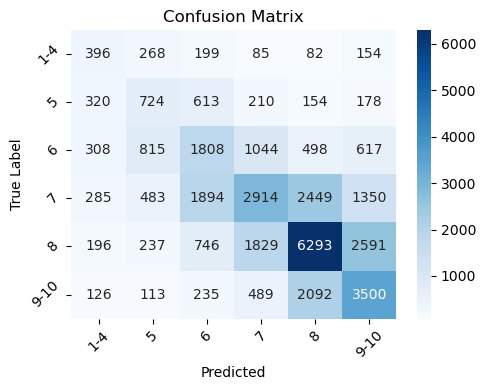

In [ ]:
label_map = {
    0: "1-4",
    1: "5",
    2: "6",
    3: "7",
    4: "8",
    5: "9-10"
}

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))

# Crea le label per gli assi usando il mapping
class_labels = [label_map[i] for i in sorted(np.unique(y_test))]

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_labels,  # Label testuali per asse X
    yticklabels=class_labels   # Label testuali per asse Y
)

plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True Label')
plt.tight_layout()  # Per migliorare il layout
plt.show()


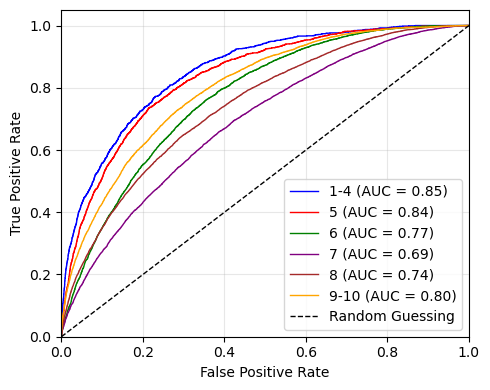


ROC AUC per classe:
1-4: 0.855
5: 0.836
6: 0.770
7: 0.690
8: 0.742
9-10: 0.799

ROC AUC media: 0.782


In [ ]:
# ROC curve per multiclass
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarizza solo le etichette di test
y_test_bin = label_binarize(y_test, classes=sorted(np.unique(y_test)))
n_classes = y_test_bin.shape[1]

# compute y_pred_proba
y_pred_proba = best_model.predict_proba(X_test)

# Calcola le curve ROC e AUC per ogni classe
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot delle curve ROC
plt.figure(figsize=(5, 4))
colors = ['blue', 'red', 'green', 'purple', 'brown', 'orange']

for i in range(n_classes):
    plt.plot(
        fpr[i], tpr[i], 
        color=colors[i % len(colors)],
        lw=1,
        label=f'{label_map[i]} (AUC = {roc_auc[i]:.2f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calcola anche la ROC AUC media
print(f"\nROC AUC per classe:")
for i in range(n_classes):
    print(f"{label_map[i]}: {roc_auc[i]:.3f}")
print(f"\nROC AUC media: {np.mean(list(roc_auc.values())):.3f}")

### AdaBoost

In [80]:
# from sklearn.ensemble import AdaBoostClassifier

# # Base learner 
# base_estimator = DecisionTreeClassifier()

# # AdaBoost setup
# adaboost = AdaBoostClassifier(
#     estimator=base_estimator,
#     random_state=42
# )

# # Parametri più ampi per halving search
# param_dist_adaboost = {
#     'n_estimators': randint(50, 400),  # range più ampio
#     'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 1.0, 1.5],  # più opzioni
#     'estimator__max_depth': [1, 2, 3, 4, 5, 6, 8],  # più profondità
#     'estimator__min_samples_split': randint(2, 15),
#     'estimator__min_samples_leaf': randint(1, 8),
#     'estimator__criterion': ['gini', 'entropy'],
#     'algorithm': ['SAMME']  # algoritmi diversi
# }

# # Halving Random Search per AdaBoost
# search_adaboost = HalvingRandomSearchCV(
#     estimator=adaboost,
#     param_distributions=param_dist_adaboost,
#     factor=1.5,  
#     resource='n_samples',  # Usa campioni crescenti
#     max_resources='auto',  # Usa tutti i campioni nell'ultima iterazione
#     scoring='f1_macro', 
#     cv=10,
#     verbose=2,
#     n_jobs=-1,
#     random_state=42
# )

# search_adaboost.fit(X_train, y_train)

# # best model fitting
# best_model = search_adaboost.best_estimator_
# print("Best params AdaBoost:", search_adaboost.best_params_)

# # store model
# import joblib
# joblib.dump(best_model, './models/adaboost_rating.pkl')

In [81]:
# load 
best_model = joblib.load('./models/adaboost_rating.pkl')

In [82]:

y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.32      0.17      0.22      1184
           1       0.31      0.19      0.23      2199
           2       0.30      0.28      0.29      5090
           3       0.35      0.39      0.37      9375
           4       0.45      0.50      0.47     11892
           5       0.36      0.32      0.34      6555

    accuracy                           0.38     36295
   macro avg       0.35      0.31      0.32     36295
weighted avg       0.37      0.38      0.37     36295



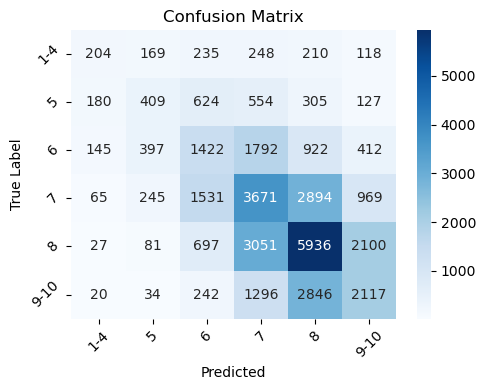

In [ ]:
label_map = {
    0: "1-4",
    1: "5",
    2: "6",
    3: "7",
    4: "8",
    5: "9-10"
}

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))

# Crea le label per gli assi usando il mapping
class_labels = [label_map[i] for i in sorted(np.unique(y_test))]

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_labels,  # Label testuali per asse X
    yticklabels=class_labels   # Label testuali per asse Y
)

plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True Label')
plt.tight_layout()  # Per migliorare il layout
plt.show()


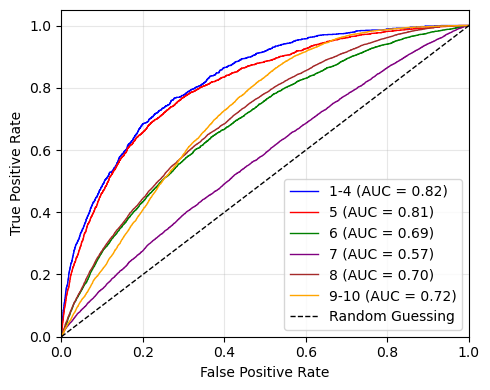


ROC AUC per classe:
1-4: 0.824
5: 0.805
6: 0.687
7: 0.569
8: 0.703
9-10: 0.717

ROC AUC media: 0.717


In [ ]:
# ROC curve per multiclass
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarizza solo le etichette di test
y_test_bin = label_binarize(y_test, classes=sorted(np.unique(y_test)))
n_classes = y_test_bin.shape[1]

# compute y_pred_proba
y_pred_proba = best_model.predict_proba(X_test)

# Calcola le curve ROC e AUC per ogni classe
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot delle curve ROC
plt.figure(figsize=(5, 4))
colors = ['blue', 'red', 'green', 'purple', 'brown', 'orange']

for i in range(n_classes):
    plt.plot(
        fpr[i], tpr[i], 
        color=colors[i % len(colors)],
        lw=1,
        label=f'{label_map[i]} (AUC = {roc_auc[i]:.2f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calcola anche la ROC AUC media
print(f"\nROC AUC per classe:")
for i in range(n_classes):
    print(f"{label_map[i]}: {roc_auc[i]:.3f}")
print(f"\nROC AUC media: {np.mean(list(roc_auc.values())):.3f}")

In [85]:
# # voting
# # load models
# bagging_model = joblib.load('./models/bagging_rating.pkl')
# rf_model = joblib.load('./models/random_forest_rating.pkl')
# ab_model = joblib.load('./models/adaboost_rating.pkl')


In [86]:
# from sklearn.ensemble import VotingClassifier
# voting_clf_hard = VotingClassifier(
#     estimators=[
#         ('bagging', bagging_model),
#         ('rf', rf_model),
#         ('ab', ab_model)
#     ],
#     voting='hard'  # Use hard voting for better performance
# )
# # Fit the voting classifier
# voting_clf_hard.fit(X_train, y_train)
# print("Voting Classifier (Hard Voting) fitted.")
# # Predict using the voting classifier
# y_pred_voting_hard = voting_clf_hard.predict(X_test)
# print(classification_report(y_test, y_pred_voting_hard))
# # confusion matrix
# cm_hard = confusion_matrix(y_test, y_pred_voting_hard)
# plt.figure(figsize=(8, 5))
# sns.heatmap(cm_hard, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
# plt.title('Confusion Matrix - Voting Classifier (Hard Voting)')
# plt.xlabel('Predicted')
# plt.ylabel('Real')
# plt.show()


In [87]:
# # store the model
# joblib.dump(voting_clf_hard, './models/voting_classifier_hard_rating.pkl')

In [88]:
# from sklearn.ensemble import VotingClassifier
# # Create a voting classifier with the three models
# voting_clf = VotingClassifier(
#     estimators=[
#         ('bagging', bagging_model),
#         ('rf', rf_model),
#         ('ab', ab_model)
#     ],
#     voting='soft'  # Use soft voting for better performance
# )
# # Fit the voting classifier
# voting_clf.fit(X_train, y_train)
# print("Voting Classifier (Soft Voting) fitted.")
# # Predict using the voting classifier
# y_pred_voting = voting_clf.predict(X_test)
# print(classification_report(y_test, y_pred_voting))
# # confusion matrix
# cm = confusion_matrix(y_test, y_pred_voting)
# plt.figure(figsize=(8, 5))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
# plt.title('Confusion Matrix - Voting Classifier')
# plt.xlabel('Predicted')
# plt.ylabel('Real')
# plt.show()
# report = classification_report(y_test, y_pred_voting, output_dict=True)


In [89]:
# # save the model
# joblib.dump(voting_clf, './models/voting_classifier_rating.pkl')